In [2]:
from utils.custom_plots import (line_plot,
                                bar_plot, 
                                scatter_plot,
                                ecdf_plot,
                                box_plot,
                                distribution_plot,
                                grouped_box_plot)
from utils.db_utils import run_query
import pandas as pd
import numpy as np

import plotly.io as pio
pio.renderers.default = "png"       # drop this two lines to get local interactive plotly charts

<div class="alert alert-block alert-success">


# **User-centric KPIs**
## **KPIs**
- **Registrations**
- **Active users**
- **Growth**
- **Retention**
### **Benefits**
- Measure **performance** well in **B2Cs**
- Used by investors to **assess** pre-revenue and -profit startups


<div class="alert alert-block alert-success">

## **Registrations** - overview
- Registration: When a user first signs up for an account on Delivr through its app
- Registrations KPI: Counts registrations over time, usually per month
- Good at measuring a company's success in attracting new users
- For Delivr, a user's registration date is the date of that user's first order


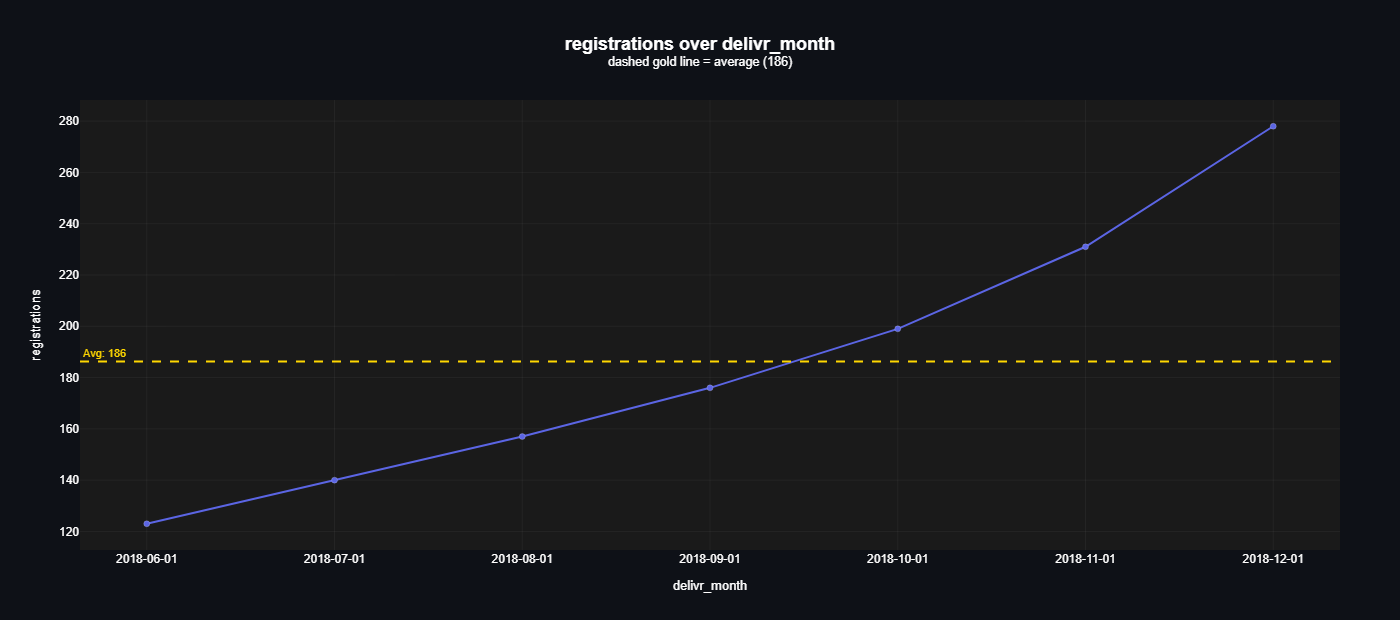

In [2]:
# registration per-month query 

reg_permonth_query = run_query('''
with regs as (
		select
			user_id,
			min(order_date) as reg_date
		from
			orders
		group by
			user_id
	)

select
	date_trunc('month', reg_date)::date as delivr_month,
	count(user_id) as registrations 
	from regs 
	group by delivr_month 
	order by delivr_month;
''')

regs_per_month_lineplot = line_plot(df=reg_permonth_query,
                                    x='delivr_month',
                                    y='registrations',
                                    avg_line=True,
                                    )

regs_per_month_lineplot

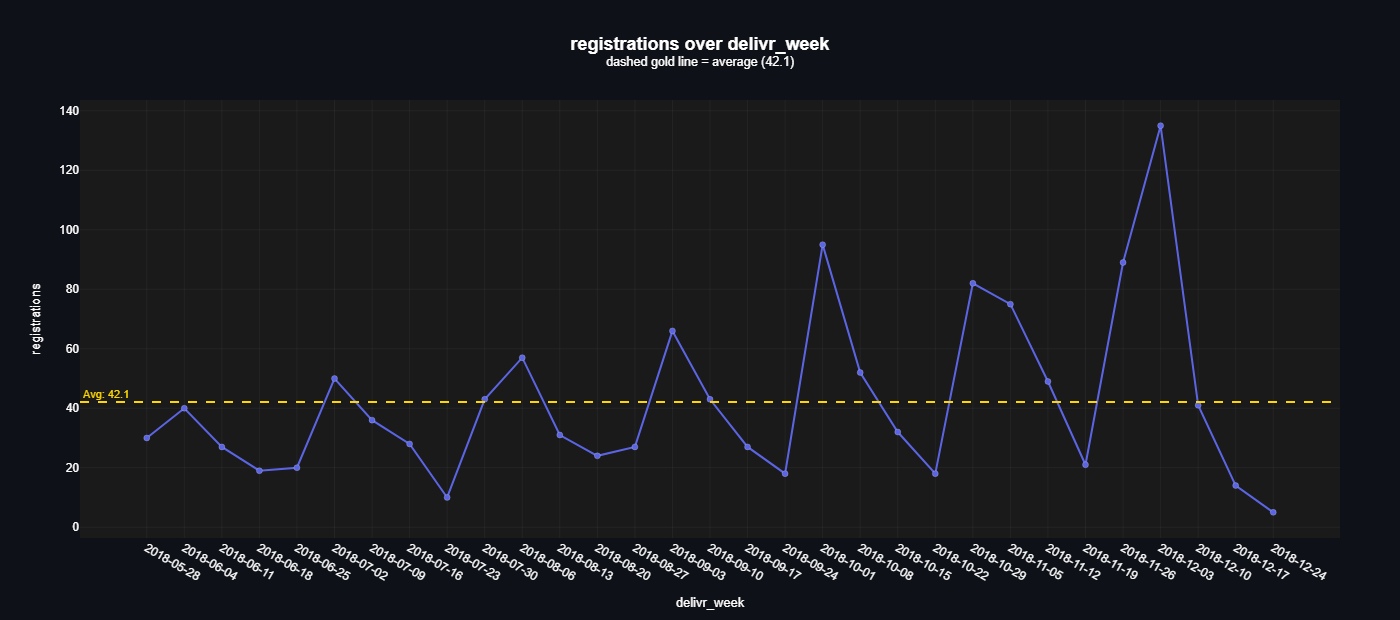

In [3]:
# registrations per week query 

reg_perweek_query = run_query('''
with regs as (
		select
			user_id,
			min(order_date) as reg_date
		from
			orders
		group by
			user_id
	)

select
	date_trunc('week', reg_date)::date as delivr_week,
	count(user_id) as registrations 
	from regs 
	group by delivr_week 
	order by delivr_week;
''')

regs_per_week_lineplot = line_plot(df=reg_perweek_query,
                                    x='delivr_week',
                                    y='registrations',
                                    avg_line=True,
                                    )

regs_per_week_lineplot

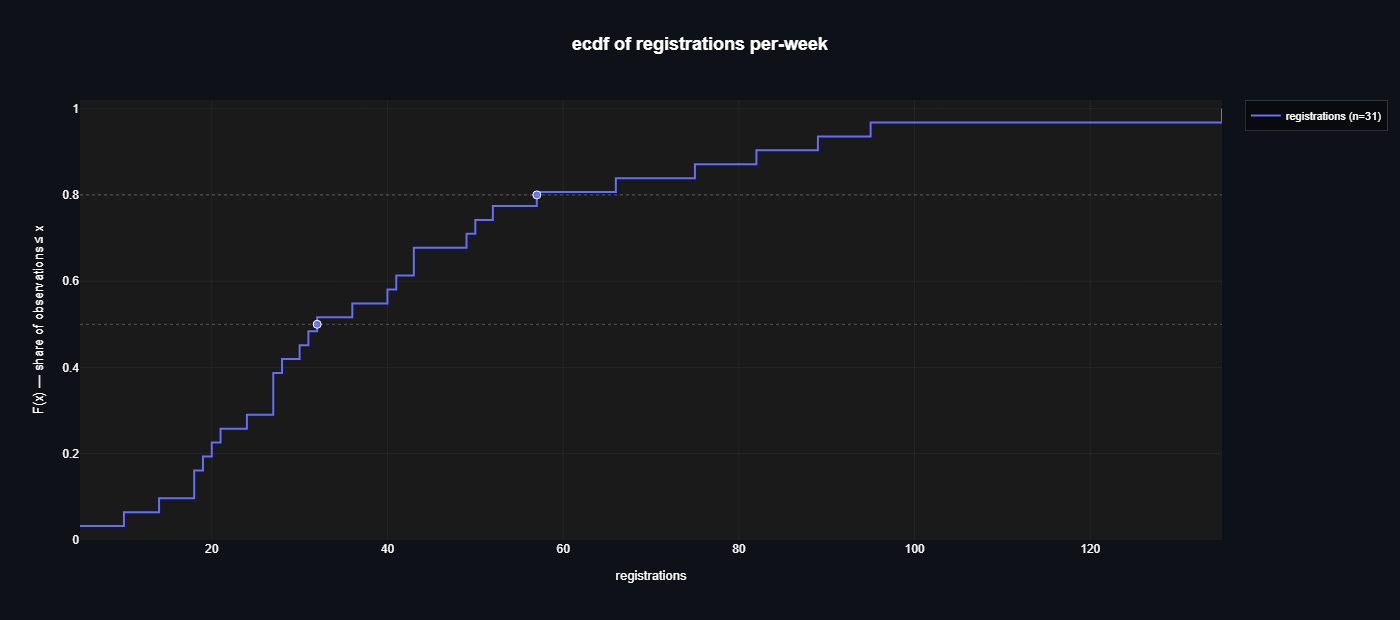

In [4]:
# ecdf plot of registrations per-week

reg_perweek_ecdf_plot = ecdf_plot(df=reg_perweek_query,
                                  cols='registrations',
                                  mark_percentiles=[0.5, 0.8],
                                  title='ecdf of registrations per-week')

reg_perweek_ecdf_plot

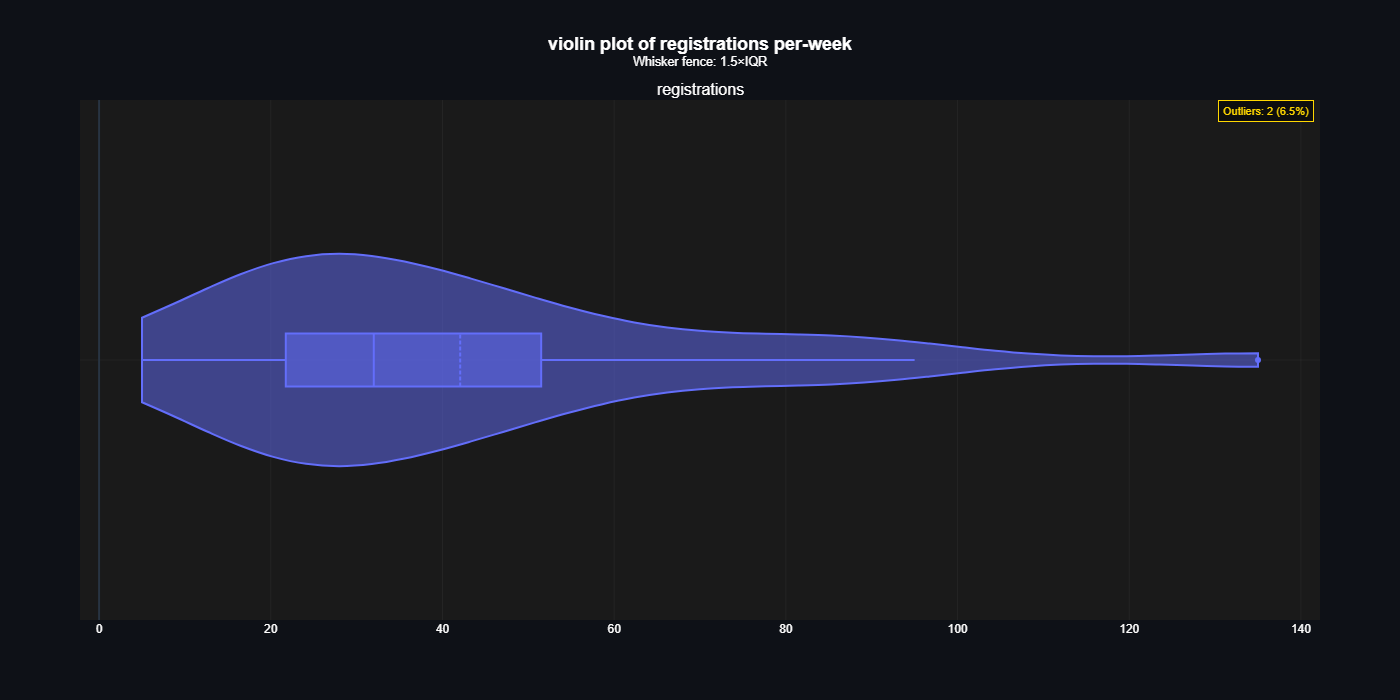

In [5]:
# violin plot of registrations per-week

reg_perweek_violin_plot = box_plot(df=reg_perweek_query,
                                   ignore_cols=['delivr_month'],
                                   kind='violin',
                                   orientation='horizontal',
                                   n_cols=1,
                                   title='violin plot of registrations per-week',
                                   height=700)
reg_perweek_violin_plot

<div class="alert alert-block alert-success">

## **Active users** - overview
- Active users KPI: Counts the active users of a company's app over a time period
- by day (daily active users, or DAU) 
- by month (monthly active users, or MAU)
- Stickiness (DAU / MAU), measures how often users engage with an app on average
- Example: If Delivr's stickiness is DAU / MAU = 0.3 (30%), users use Delivr for $30% x 30$days = 9 days each month on average

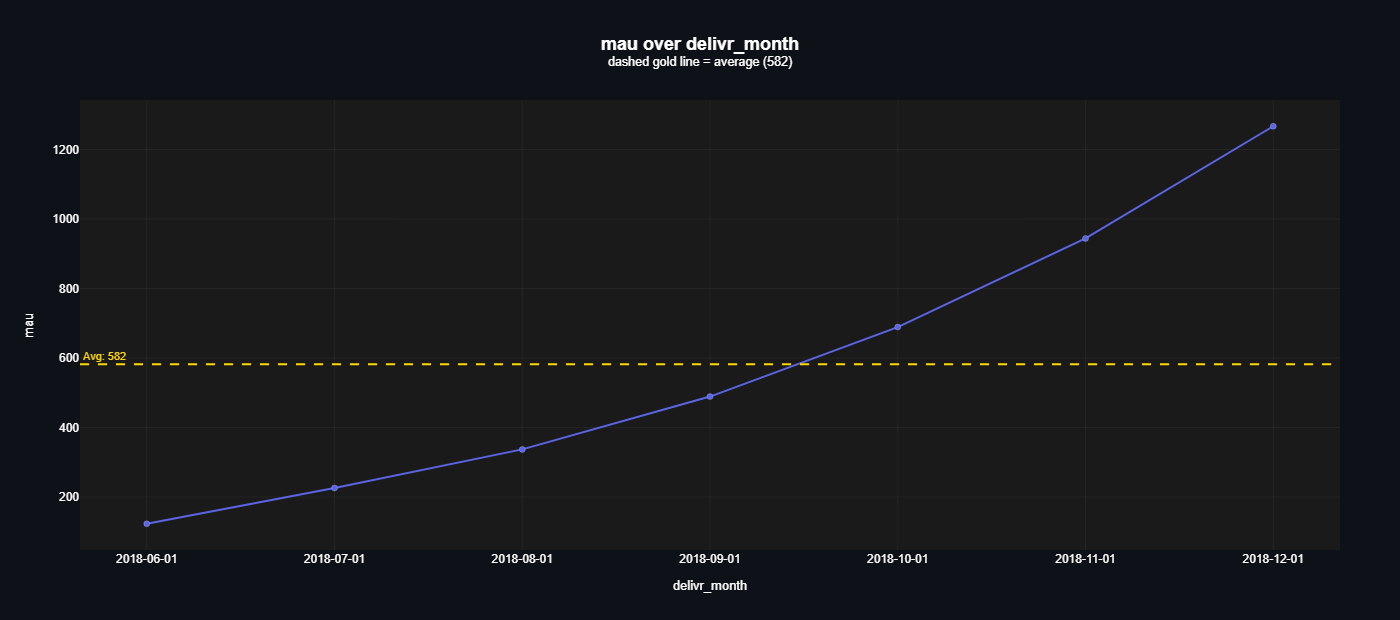

In [6]:
# active users per-month query

mau_query = run_query('''
select
	date_trunc('month', order_date)::date as delivr_month,
	count(distinct user_id) as mau
from orders 
group by delivr_month
order by delivr_month;
''')

mau_line_plot = line_plot(df=mau_query,
                          x='delivr_month',
                          y='mau',
                          avg_line=True,
                          )
mau_line_plot

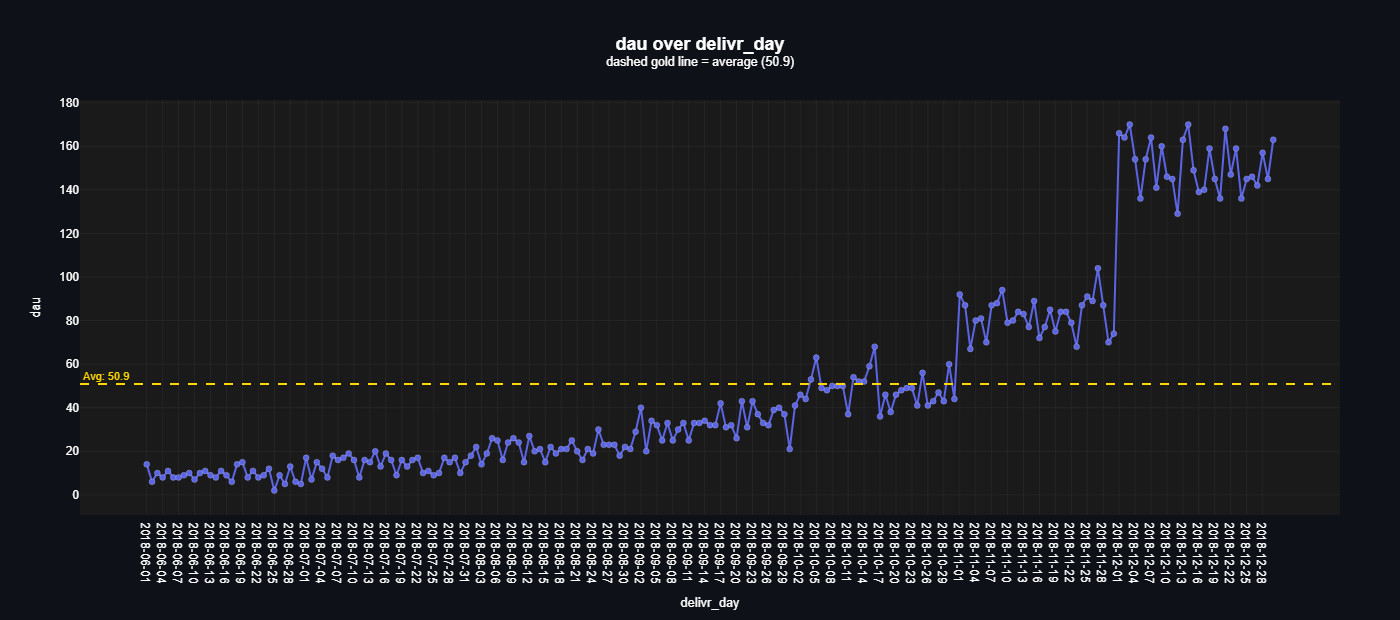

In [7]:
# active users per-day query

dau_query = run_query('''
select
	date_trunc('day', order_date)::date as delivr_day,
	count(distinct user_id) as dau
from orders 
group by delivr_day
order by delivr_day;
''')

dau_line_plot = line_plot(df=dau_query,
                          x='delivr_day',
                          y='dau',
                          avg_line=True,

                          )
dau_line_plot

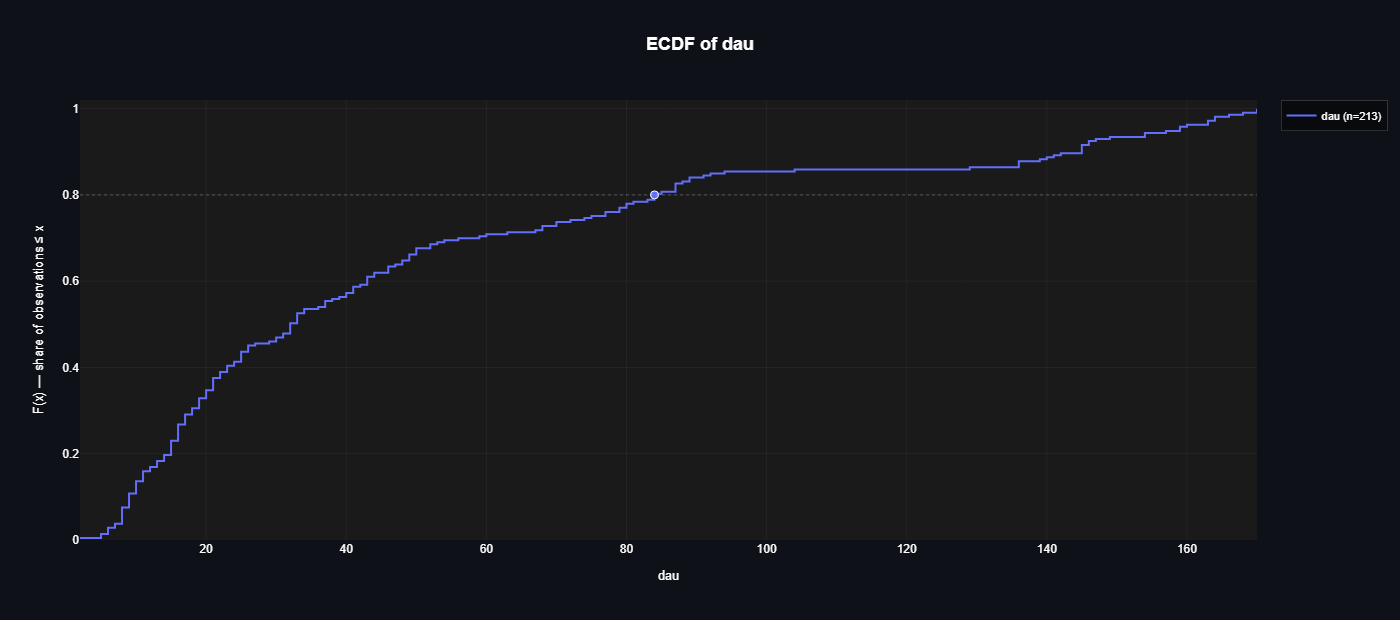

In [8]:
# ecdf plot of daily active users

dau_ecdf_plot = ecdf_plot(df=dau_query,
                          cols='dau',
                          mark_percentiles=[0.8]
                          )
dau_ecdf_plot

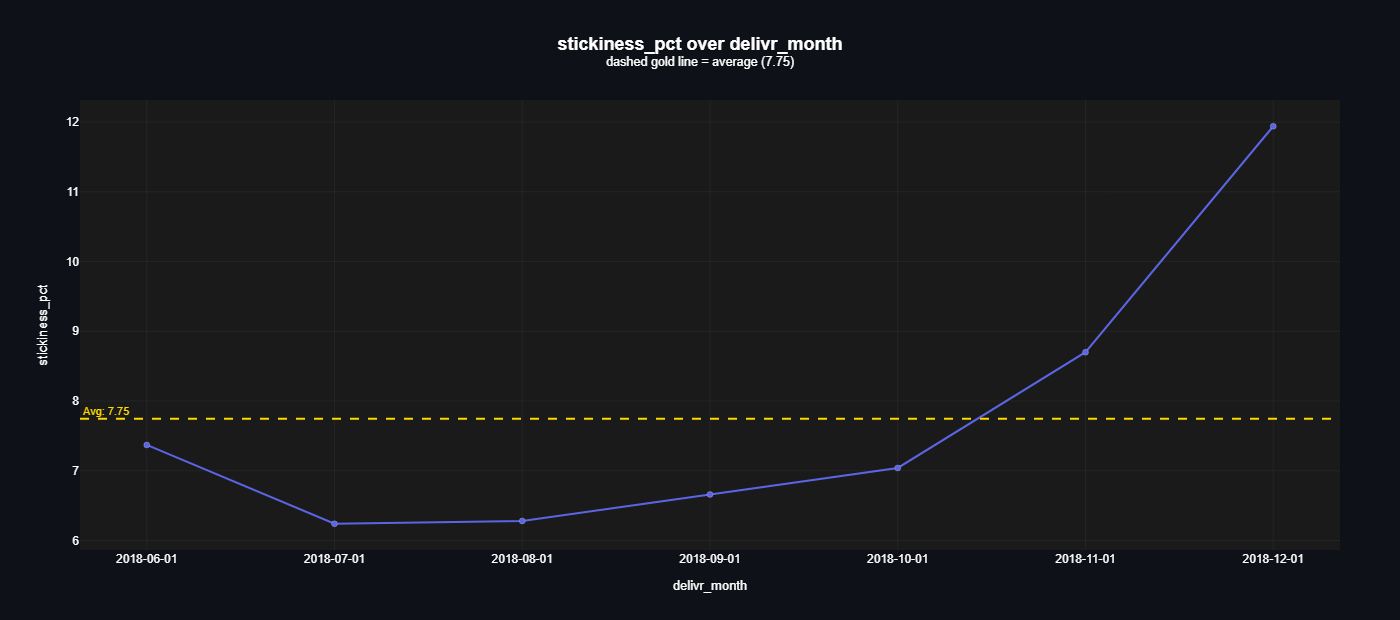

In [ ]:
# per-month stickiness query 
# we measure it by dividing the average dau during a month by mau

per_month_stickiness_query = run_query('''
WITH
	avg_monthly_dau AS (
		SELECT
			date_trunc('month', delivr_day)::DATE  AS delivr_month,
			avg(dau)                               AS avg_monthly_dau
		FROM
			(
				SELECT
					date_trunc('day', order_date)::DATE  AS delivr_day,
					count(DISTINCT user_id)              AS dau
				FROM
					orders
				GROUP BY
					delivr_day
			)
		GROUP BY
			delivr_month
	),
	mau AS (
		SELECT
			date_trunc('month', order_date)::DATE  AS delivr_month,
			count(DISTINCT user_id)                AS mau
		FROM
			orders
		GROUP BY
			delivr_month
	)
SELECT
	delivr_month,
	round(avg_monthly_dau / mau, 4) * 100  AS stickiness_pct
FROM
	avg_monthly_dau
	INNER JOIN mau USING (delivr_month)
ORDER BY
	delivr_month;
''')

per_month_stickiness_line_plot = line_plot(df=per_month_stickiness_query,
                                           x='delivr_month',
                                           y='stickiness_pct',
                                           avg_line=True,
                                           )
per_month_stickiness_line_plot

### Monthly stickiness represents how frequently monthly active users use the platform. For example, average stickiness of delivr across all months is 7.75%, **it means that an average delivr monthly active user is active on approximately 7.75% of the days in the month, or about 2.3 days out of 30.**

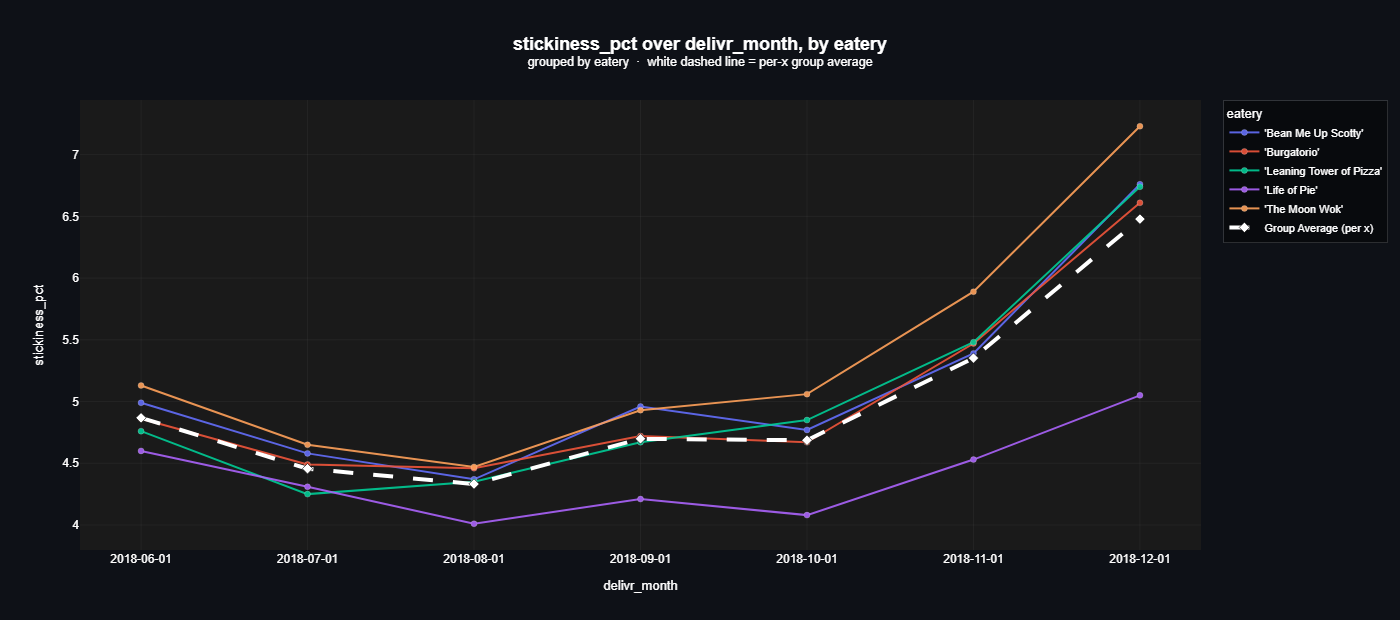

In [11]:
# lets analyze the per-eatery stickiness in each month

month_eatery_stickiness_query = run_query('''
WITH
	avg_monthly_dau AS (
		SELECT
			eatery,
			date_trunc('month', delivr_day)::date  AS delivr_month,
			avg(dau)                               AS avg_monthly_dau
		FROM
			(
				SELECT
					eatery,
					date_trunc('day', order_date)::date  AS delivr_day,
					count(DISTINCT user_id)              AS dau
				FROM
					orders
					INNER JOIN meals USING (meal_id)
				GROUP BY
					delivr_day,
					eatery
			)
		GROUP BY
			delivr_month,
			eatery
	),
	mau AS (
		SELECT
			eatery,
			date_trunc('month', order_date)::date  AS delivr_month,
			count(DISTINCT user_id)                AS mau
		FROM
			orders
			INNER JOIN meals USING (meal_id)
		GROUP BY
			delivr_month,
			eatery
	)
SELECT
	mau.eatery,
	mau.delivr_month,
	round((avg_monthly_dau / mau) * 100, 2)  AS stickiness_pct
FROM
	avg_monthly_dau AS amdau
	INNER JOIN mau ON mau.delivr_month = amdau.delivr_month
	AND mau.eatery = amdau.eatery
ORDER BY
	delivr_month,
	eatery;
''')


per_eatery_stickiness_lineplot = line_plot(df=month_eatery_stickiness_query,
                                           x='delivr_month',
                                           y='stickiness_pct',
                                           group_col='eatery',
                                           avg_group_line=True)
per_eatery_stickiness_lineplot

<div class="alert alert-block alert-success">

## **Window functions** - overview
- Window functions: Perform an operation across a set of rows related to the current row
- Examples:
  - Calculate a running total
  - Do running window calculations
  - Fetch the value of a previous or following row

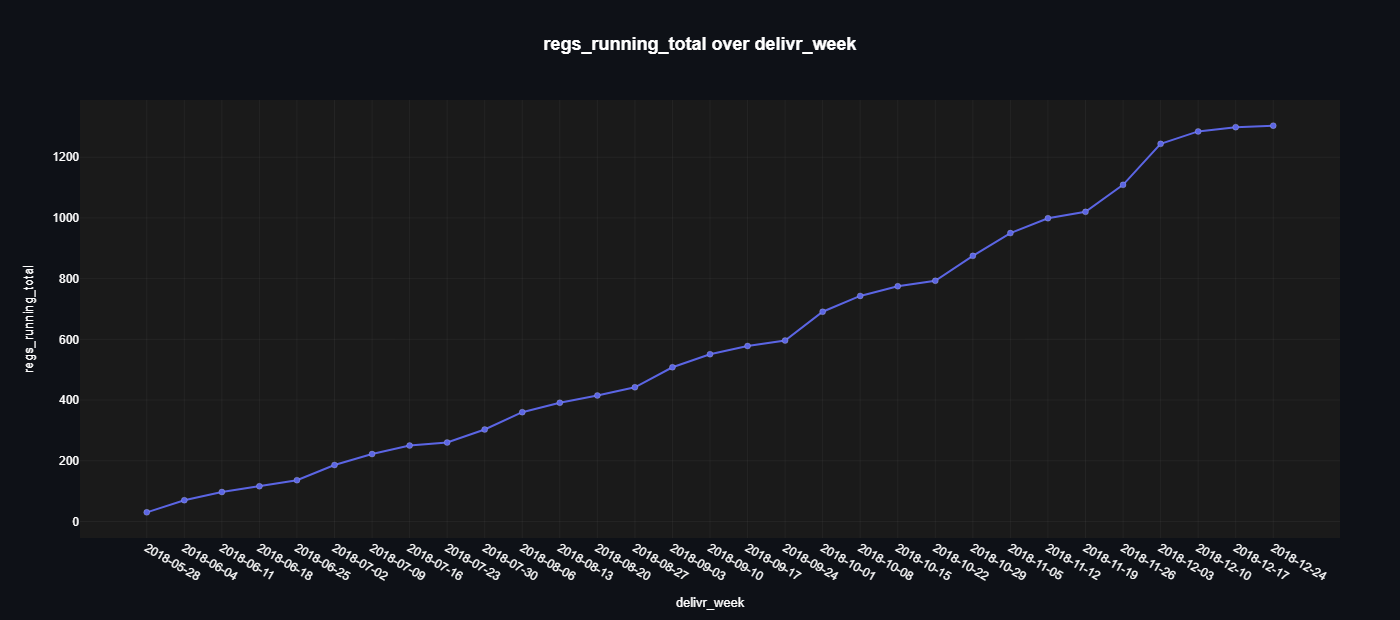

In [7]:
# per-week registrations running total query

regs_running_total_query = run_query('''
WITH
	registrations AS (
		SELECT
			user_id,
			min(order_date)  AS reg_date
		FROM
			orders
		GROUP BY
			user_id
	),
	regs_perweek AS (
		SELECT
			date_trunc('week', reg_date)::date   AS delivr_week,
			count(user_id)                       AS reg_count
		FROM
			registrations
		GROUP BY
			delivr_week
	)
SELECT
	delivr_week,
	sum(reg_count) OVER (
		ORDER BY
			delivr_week ASC
	)  AS regs_running_total
FROM
	regs_perweek
ORDER BY
	delivr_week
''')

regs_rt_perweek_lineplot = line_plot(df=regs_running_total_query,
                                      x='delivr_week',
                                      y='regs_running_total',
                                      )
regs_rt_perweek_lineplot

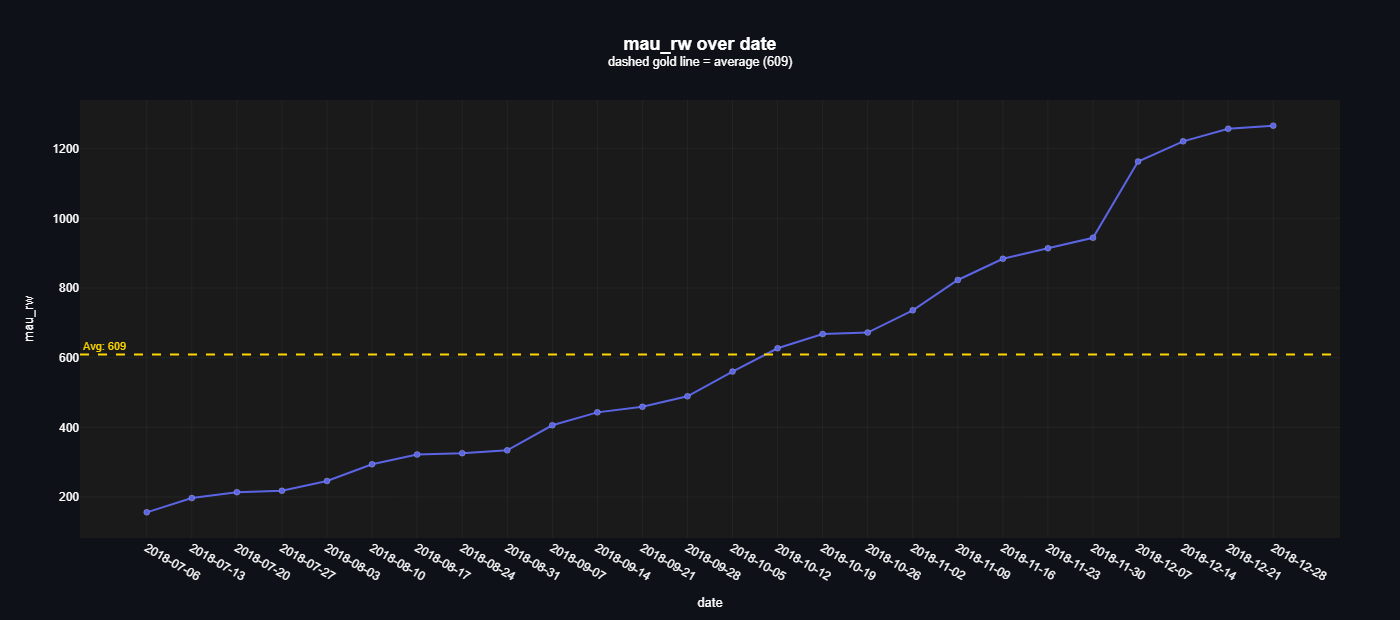

In [ ]:
# mau running window query
# this query doesn't use window functions because its not possible in mau context.

mau_rw_query = run_query('''
WITH date_range AS (
    SELECT
        generate_series(
            MIN(order_date),
            MAX(order_date),
            INTERVAL '7 days'  -- weekly interval to reduce data points for a clearer lineplot 
        )::date AS date
    FROM orders
),

running_mau AS (
    SELECT
        d.date,
        COUNT(DISTINCT o.user_id) AS mau_rw
    FROM date_range AS d
    INNER JOIN orders AS o
        ON o.order_date BETWEEN d.date - 29 AND d.date
    GROUP BY d.date
)

SELECT
    date,
    mau_rw
FROM running_mau
WHERE date >= (
    SELECT MIN(order_date) + 29
    FROM orders
)
ORDER BY date;
''')


mau_rw_lineplot = line_plot(df=mau_rw_query,
                             x='date',
                             y='mau_rw',
                             avg_line=True)
mau_rw_lineplot

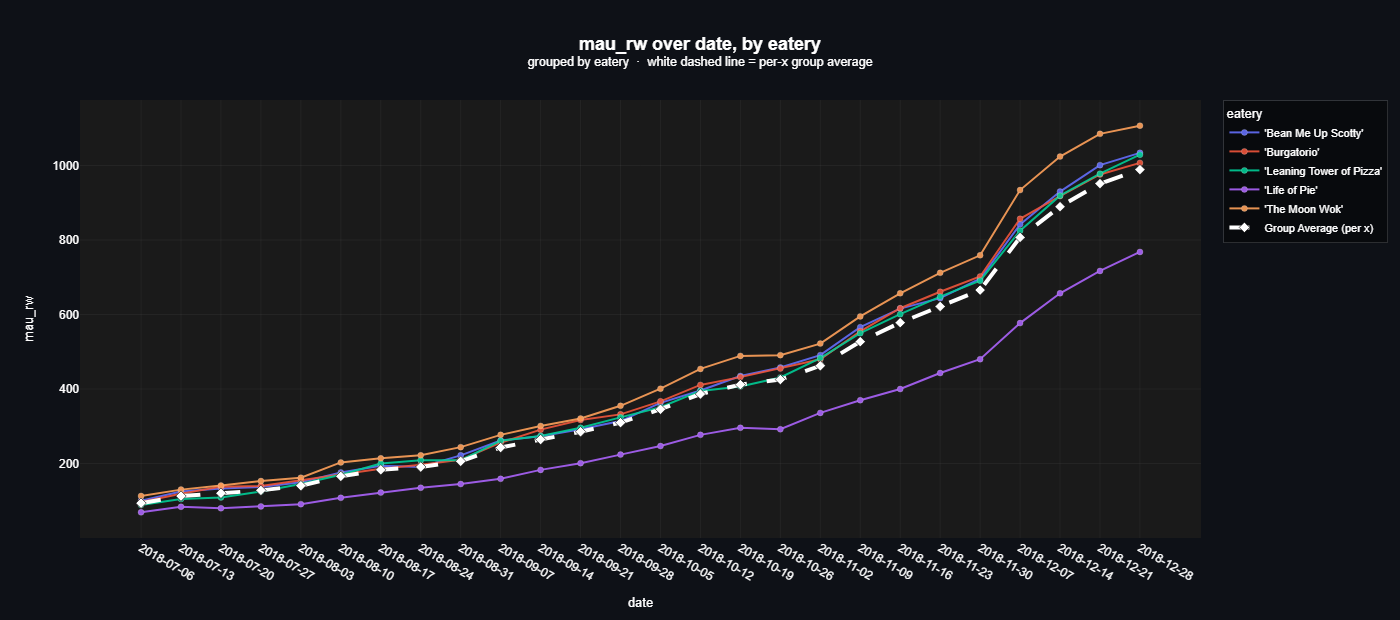

In [ ]:
# mau running total query calculated per-eatery for better comparability 
# this query doesn't use window functions because its not possible in mau context.

mau_rw_pereatery_query = run_query('''
WITH date_range AS (
    SELECT
        generate_series(
            MIN(order_date),
            MAX(order_date),
            INTERVAL '7 days' -- weekly interval to reduce data points for clearer lineplot 
        )::date AS date
    FROM orders
),

running_mau AS (
    SELECT
		m.eatery,
        d.date,
        COUNT(DISTINCT o.user_id) AS mau_rw
    FROM date_range AS d
    INNER JOIN orders AS o
        ON o.order_date BETWEEN d.date - 29 AND d.date
	inner join meals as m on m.meal_id = o.meal_id
    GROUP BY d.date, m.eatery
)

SELECT
	eatery,
    date,
    mau_rw
FROM running_mau
WHERE date >= (
    SELECT MIN(order_date) + 29
    FROM orders
)
ORDER BY date;
''')


mau_rw_pereatery_lineplot = line_plot(df=mau_rw_pereatery_query,
                                      x='date',
                                      y='mau_rw',
                                      group_col='eatery',
                                      avg_group_line=True)

mau_rw_pereatery_lineplot

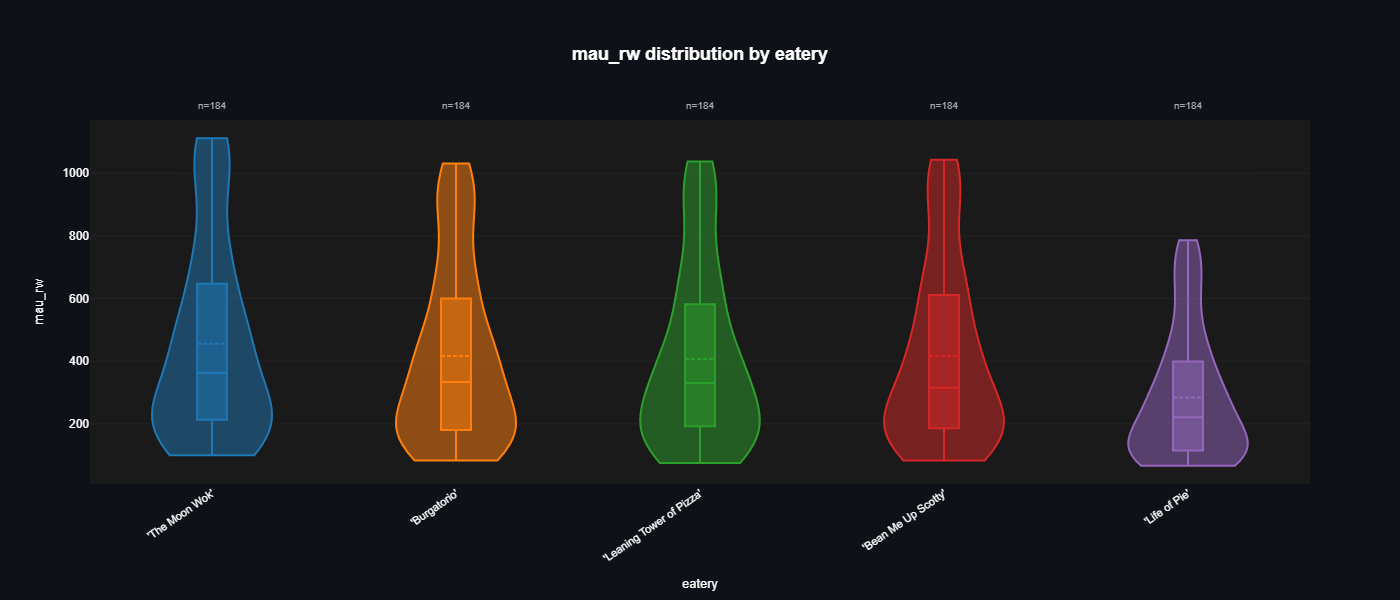

In [ ]:
# grouped violin plot of mau running total per-eatery
# this query doesn't use window functions because its not possible in mau context.

mau_rw_pereatery_query_dense = run_query('''
WITH date_range AS (
    SELECT
        generate_series(
            MIN(order_date),
            MAX(order_date),
            INTERVAL '1 day'  
        )::date AS date
    FROM orders
),

running_mau AS (
    SELECT
		m.eatery,
        d.date,
        COUNT(DISTINCT o.user_id) AS mau_rw
    FROM date_range AS d
    INNER JOIN orders AS o
        ON o.order_date BETWEEN d.date - 29 AND d.date
	inner join meals as m on m.meal_id = o.meal_id
    GROUP BY d.date, m.eatery
)

SELECT
	eatery,
    date,
    mau_rw
FROM running_mau
WHERE date >= (
    SELECT MIN(order_date) + 29
    FROM orders
)
ORDER BY date;
''')

mau_rw_pereatery_violin_plot = grouped_box_plot(df=mau_rw_pereatery_query_dense,
                                                group_col='eatery',
                                                value_col='mau_rw',
                                                kind='violin',
                                                sort_by='median',
                                                orientation='vertical')
mau_rw_pereatery_violin_plot

<div class="alert alert-block alert-success">

## **Growth rate** - overview

- Growth rate: A percentage that show the change in a variable over time relative to that variable's initial value

- Formula: $\frac{\textit{Current value} - \textit{Previous value}}{\textit{Previous value}}$

- Example: $\frac{67-50}{50} = 0.34 = 34\%$

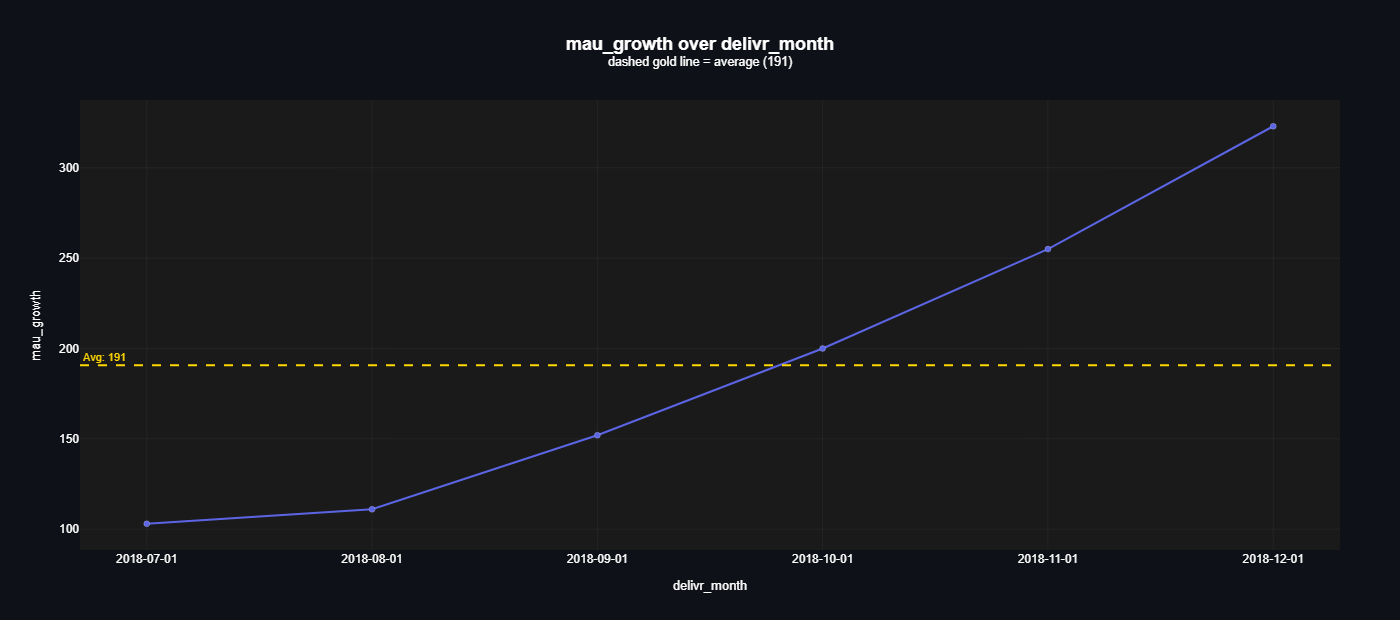

In [ ]:
# mau growth query 

mau_growth_query = run_query('''
WITH mau AS (
    SELECT date_trunc('month', order_date)::date AS delivr_month,
           count(DISTINCT user_id) as mau
    FROM orders
    GROUP BY delivr_month
),
mau_lag AS (
    SELECT delivr_month,
           mau,
           lag(mau) OVER (ORDER BY delivr_month) AS last_mau
    FROM mau
)
SELECT delivr_month,
       mau - last_mau AS mau_growth,
       round((((mau - last_mau)::numeric / last_mau) * 100), 2) AS mau_growth_rate_pct
       -- MoM mau_growth_rate 
FROM mau_lag;
''')

mau_growth_lineplot = line_plot(df=mau_growth_query,
                                x='delivr_month',
                                y='mau_growth',
                                avg_line=True)
mau_growth_lineplot

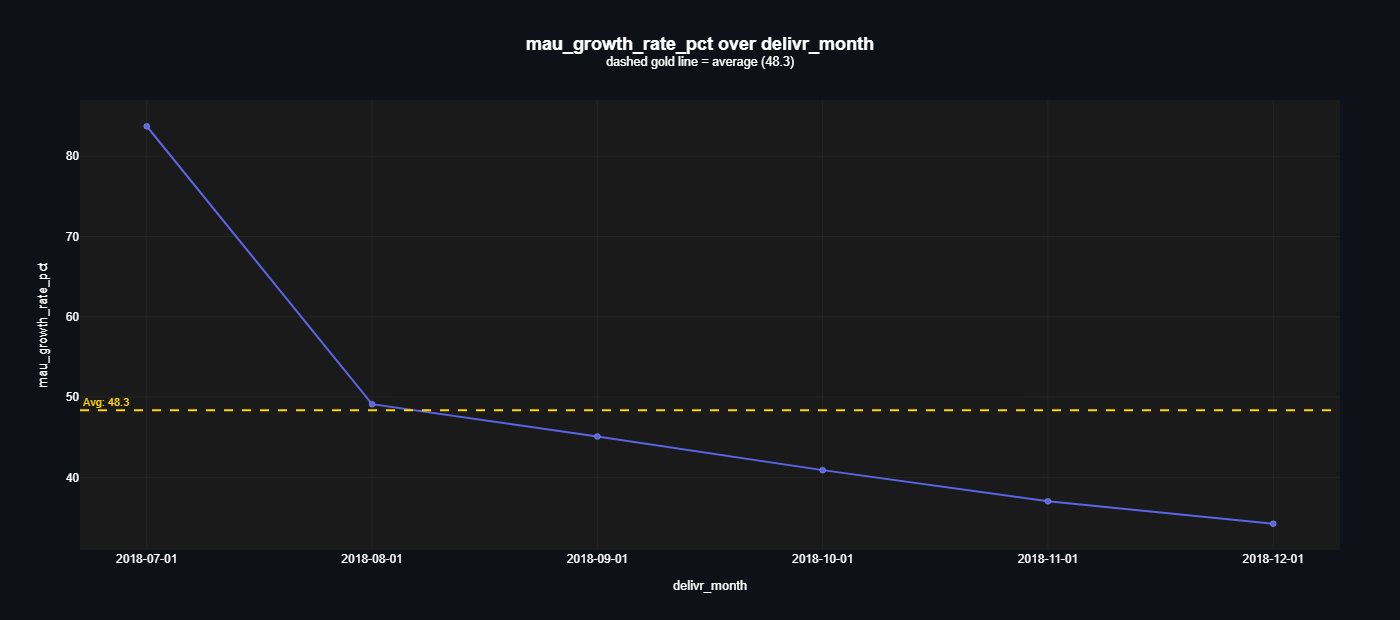

In [ ]:
mau_growth_rate_pct_lineplot = line_plot(df=mau_growth_query,
                                         x='delivr_month',
                                         y='mau_growth_rate_pct',
                                         avg_line=True)
mau_growth_rate_pct_lineplot

### Important distinction based on two previous lineplots: 
- if we only looked at the mau_growth lineplot, we may think that delivrs growth rate is increasing because each month mau delta is higher than last month's mau delta but that is not true, as we can see in mau_growth_rate_pct the growth rate is actually decreasing per-month. 
- That is because mau_growth_rate kpi is standardized by the last month's mau so it shows the growth significance, but mau_growth only shows the difference.

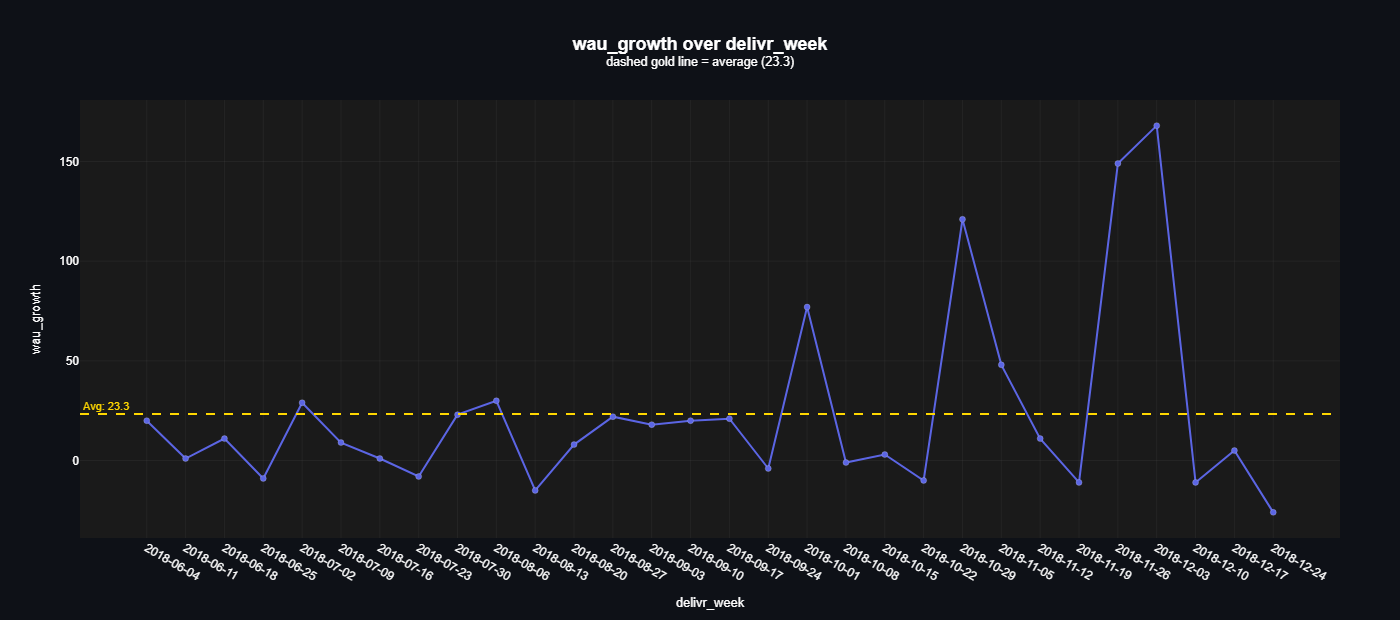

In [10]:
# wau(weekly active users) growth rate query  

wau_growth_rate_query = run_query('''
WITH wau AS (
    SELECT date_trunc('week', order_date)::date AS delivr_week,
           count(DISTINCT user_id) as wau
    FROM orders
    GROUP BY delivr_week
),
wau_lag AS (
    SELECT delivr_week,
           wau,
           lag(wau) OVER (ORDER BY delivr_week) AS last_wau
    FROM wau
)
SELECT delivr_week,
       wau - last_wau AS wau_growth,
       round((((wau - last_wau)::numeric / last_wau) * 100), 2) AS wau_growth_rate_pct
FROM wau_lag;
''')

wau_growth_lineplot = line_plot(df=wau_growth_rate_query,
                                x='delivr_week',
                                y='wau_growth',
                                avg_line=True)
wau_growth_lineplot

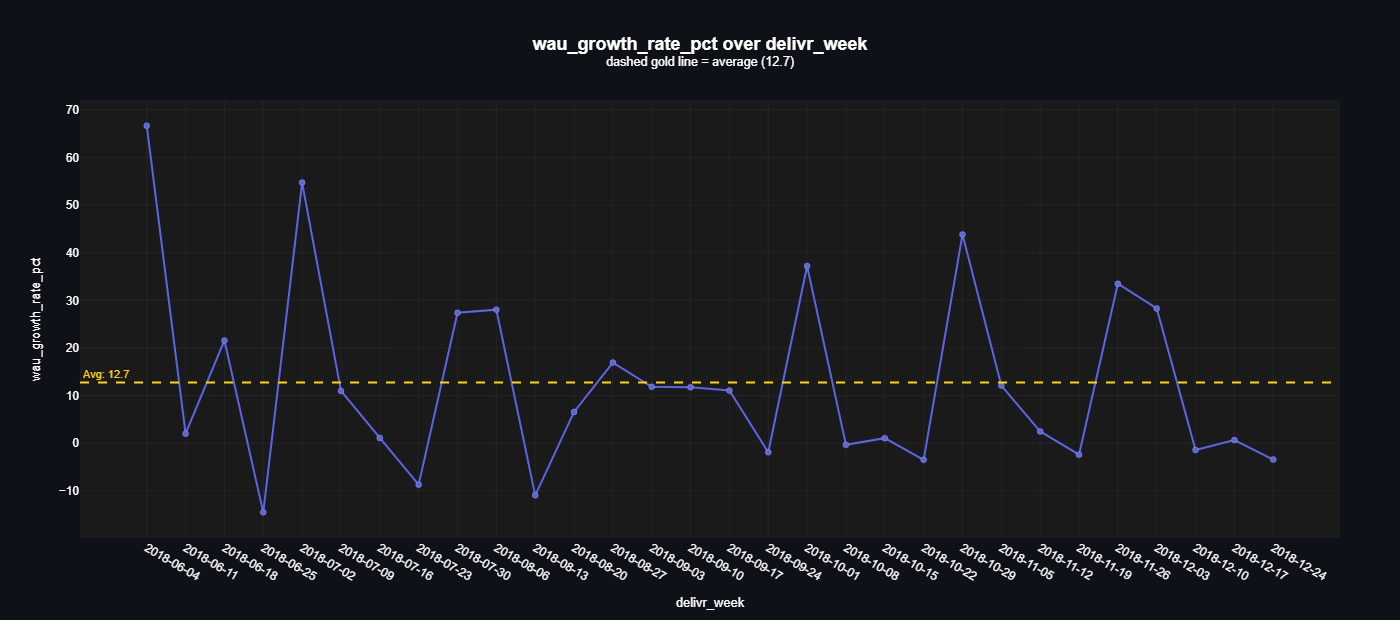

In [ ]:
wau_growth_rate_lineplot = line_plot(df=wau_growth_rate_query,
                                     x='delivr_week',
                                     y='wau_growth_rate_pct',
                                     avg_line=True)
wau_growth_rate_lineplot

# this plot has a 4 week apart peek signals

In [ ]:
# MoM order growth rate query

In [ ]:
# MoM order growth rate per-eatery query 